In [3]:
import pandas as pd
!pip install matplotlib seaborn pandas
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm


In [4]:
#폰트 확인

for f in fm.fontManager.ttflist:
  name = f.name
  if any(k in name for k in ['Gothic', 'Malgun', 'Nanum', 'Apple', 'Batang', 'Gulim']):
      print(name)

#나눔고딕 폰트로 그래프 폰트 변경(한글 깨짐 방지)
fm._load_fontmanager(try_read_cache=False)
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

Yu Gothic
Yu Gothic Light
Yu Gothic UI
Yu Gothic UI Light
Malgun Gothic
MS Gothic
MS UI Gothic
MS PGothic
Malgun Gothic
Yu Gothic
Yu Gothic Medium
Yu Gothic UI
HCR Batang
HCR Batang
HCR Batang ExtB
HCR Batang Ext
Franklin Gothic Medium
Hancom Gothic
Batang
BatangChe
Yu Gothic
Yu Gothic UI
Yu Gothic UI
Yu Gothic UI Semibold
HCR Batang ExtB
Gulim
GulimChe
Yu Gothic
Yu Gothic UI
Yu Gothic UI Semilight
Hancom Gothic
Malgun Gothic
Malgun Gothic Semilight
Franklin Gothic Medium


In [5]:
df = pd.read_csv('가스_인구_기온_통합.csv',encoding='cp949')
df

,연월,시도,월평균기온,월평균최고기온,월평균최저기온,가구수(개),공급량(㎥),총인구수
0,2021-01,강원,-4.2,1.5,-9.7,386599,51918.194190,1541696
1,2021-02,강원,1.3,7.3,-4.6,387774,43068.962620,1540875
2,2021-03,강원,7.0,13.3,1.3,388403,32782.803000,1536399
3,2021-04,강원,11.8,17.9,5.7,390610,20762.350470,1536175
4,2021-05,강원,15.3,21.1,10.0,391098,14472.110240,1535491
...,...,...,...,...,...,...,...,...
1183,2026-02,충북,1.1,7.7,-5.0,584666,47598.860310,1596816
1184,2026-03,충북,6.8,13.6,0.5,579452,39099.270910,1597976
1185,2026-04,충북,13.5,20.6,6.4,576171,21893.604080,1599375
1186,2026-05,충북,18.6,25.5,11.8,576065,12157.524940,1600216


In [6]:
#결측치 유무 판단
df.isnull().sum()

연월         0
시도         0
월평균기온      0
월평균최고기온    0
월평균최저기온    0
가구수(개)     0
공급량(㎥)     0
총인구수       0
dtype: int64

In [7]:
#각 열에 대한 식별자를 판단
len(df) #전체 데이터의 갯수
df.nunique()   #unique 고유한 값의 갯수 파악 => 전체 데이터의 갯수와 비슷하다? = 식별자

#df.nunique() / len(df) 로 유일값 비율 계산 → 1에 가까우면 식별자.
unique_rate = df.nunique() / len(df)
print(unique_rate.sort_values(ascending=False))

총인구수       0.999158
공급량(㎥)     0.998316
가구수(개)     0.997475
월평균최저기온    0.281987
월평균최고기온    0.259259
월평균기온      0.253367
연월         0.055556
시도         0.015152
dtype: float64


In [8]:
#시각화(차트)를 위한 라이브러리 설치
!pip install matplotlib seaborn scipy

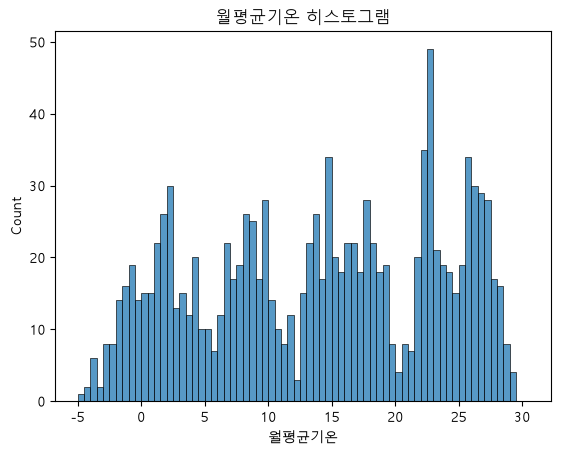

In [9]:
#히스토그램으로 가스공급량 데이터의 분포를 확인
import numpy as np
sns.histplot(df['월평균기온'], bins=np.arange(-5, 31, 0.5))
plt.title('월평균기온 히스토그램')
plt.show()

In [10]:
df['월평균기온'].max()      #29.3
df['월평균기온'].min()      #-4.8
df['월평균최고기온'].max()   #34.4
df['월평균최저기온'].min()   #-10.3

np.float64(-10.3)

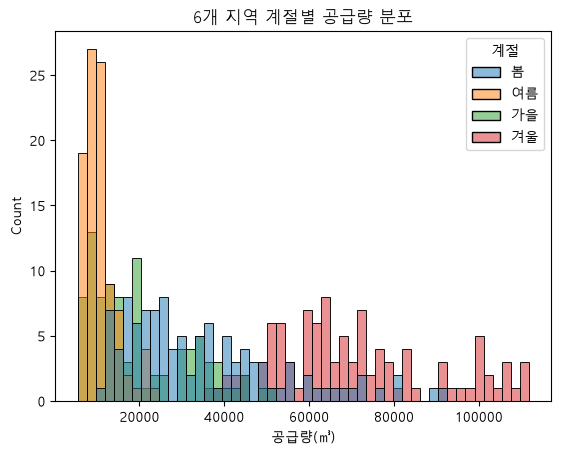

In [ ]:
#월을 계절로 매핑 함수 정의
def get_season(m) : 
  if m in [3,4,5] : return '봄'
  elif m in [6,7,8] : return '여름'
  elif m in [9,10,11] : return '가을'
  else :  return '겨울'

#지역별 데이터 정리
target = ['전북','대전','경남','경북','광주','강원']
filtered_df = df[df['시도'].isin(target)].copy()

#컬럼에서 month 추출 후 계절 이름 매핑
filtered_df['월'] = pd.to_datetime(filtered_df['연월']).dt.month
filtered_df['계절'] = filtered_df['월'].apply(get_season)

sns.histplot(
  data=filtered_df,
  x='공급량(㎥)',
  hue='계절',
  bins=50,
  hue_order=['봄', '여름', '가을', '겨울']
)

plt.title('6개 지역 계절별 공급량 분포')
plt.show()

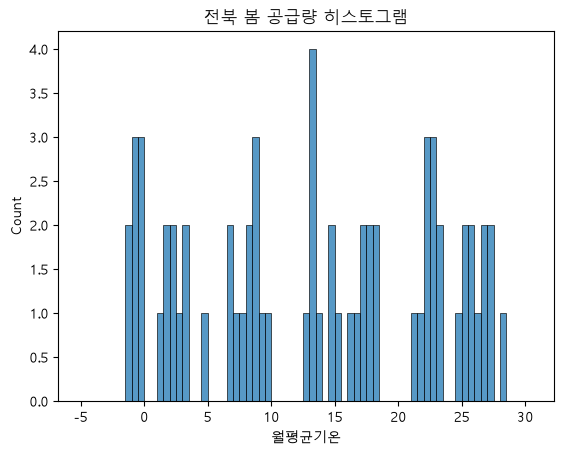

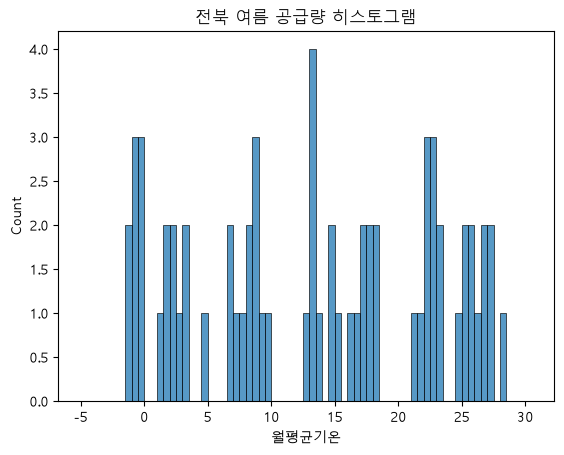

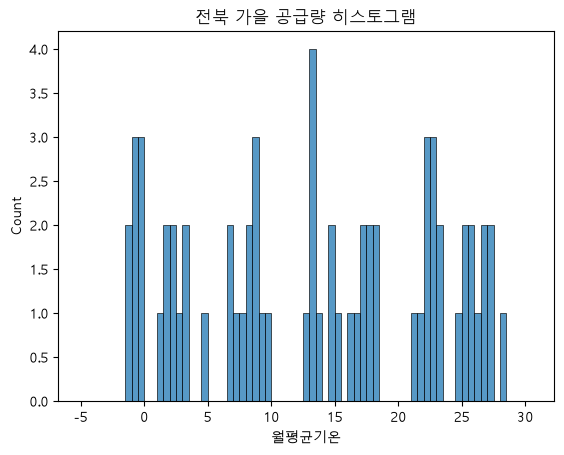

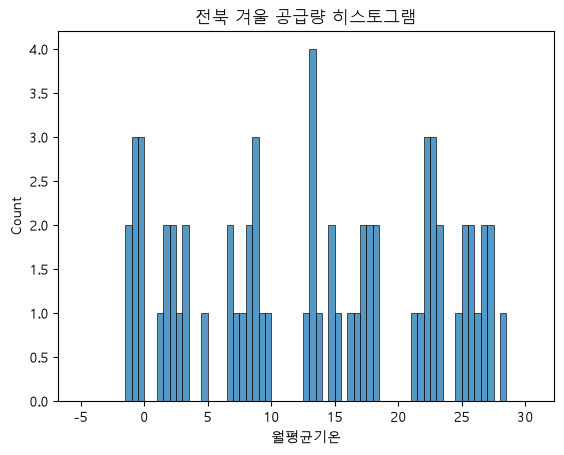

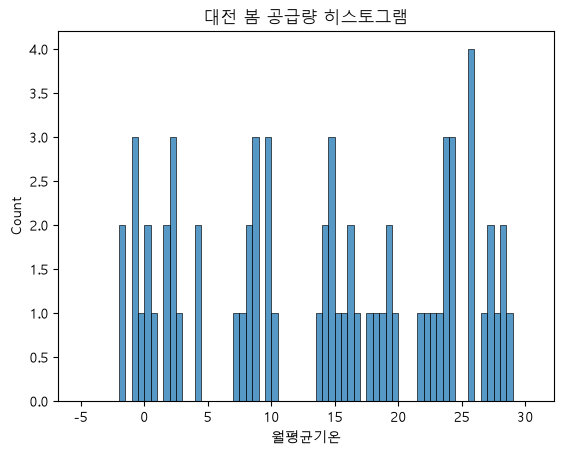

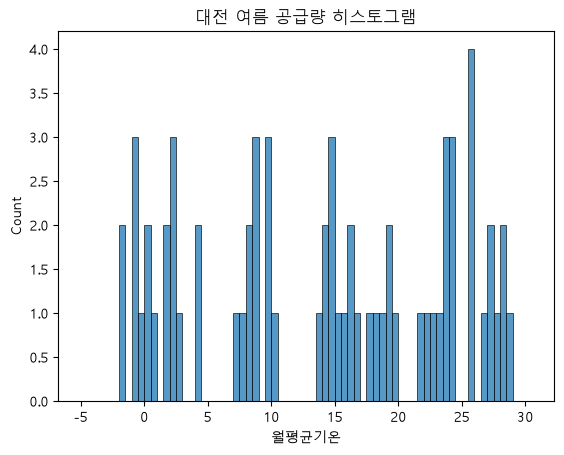

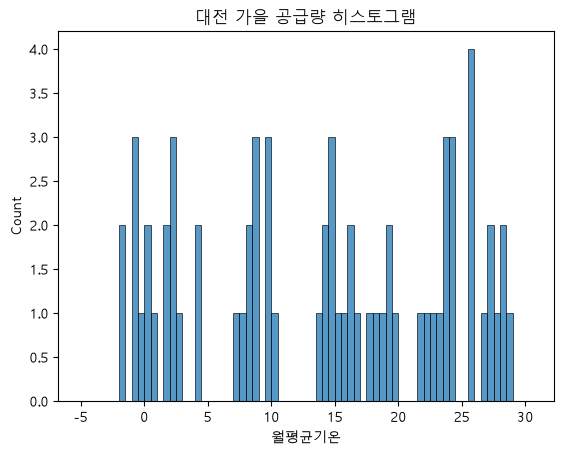

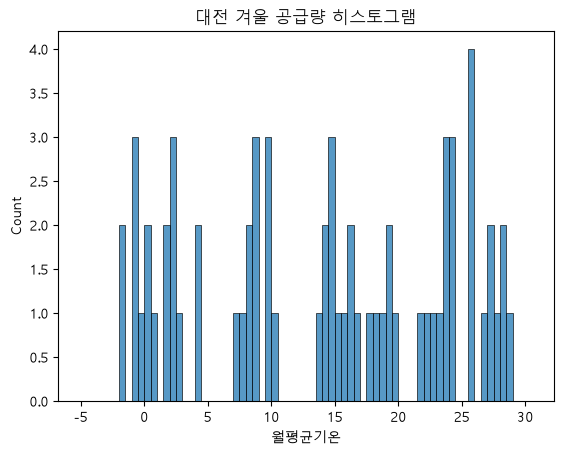

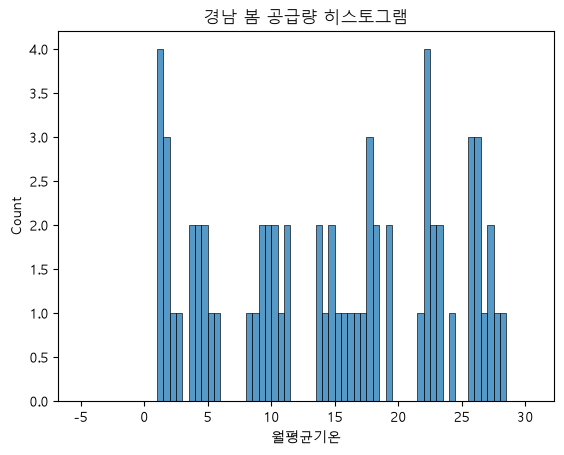

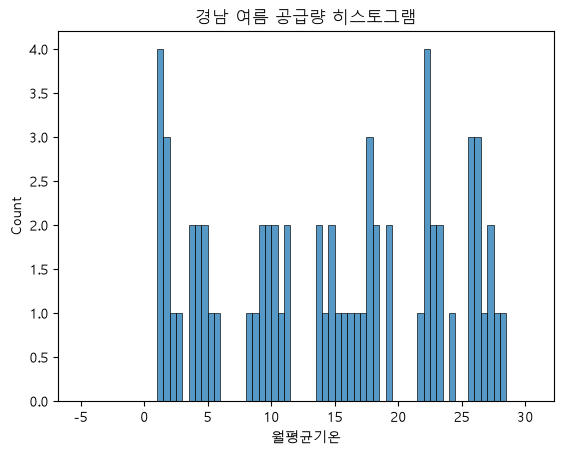

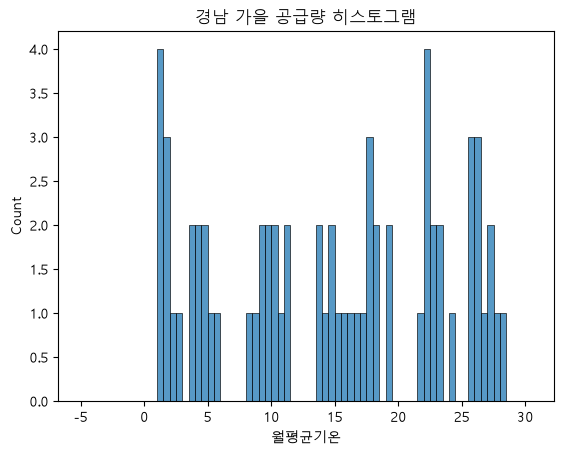

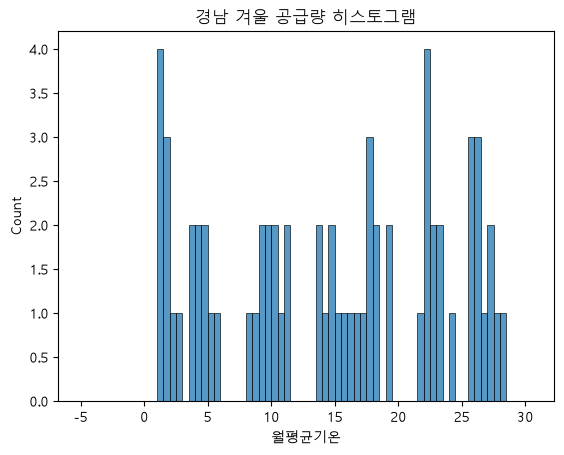

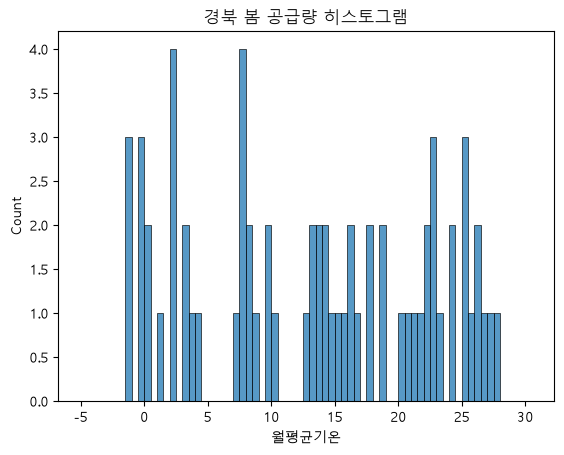

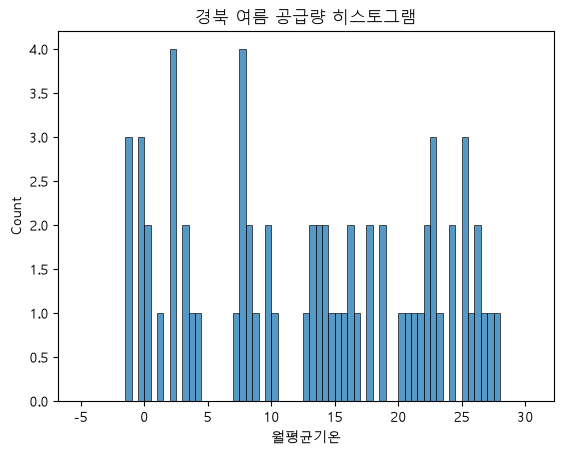

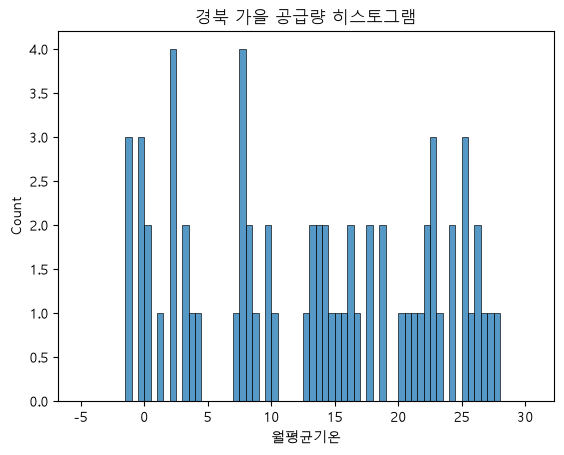

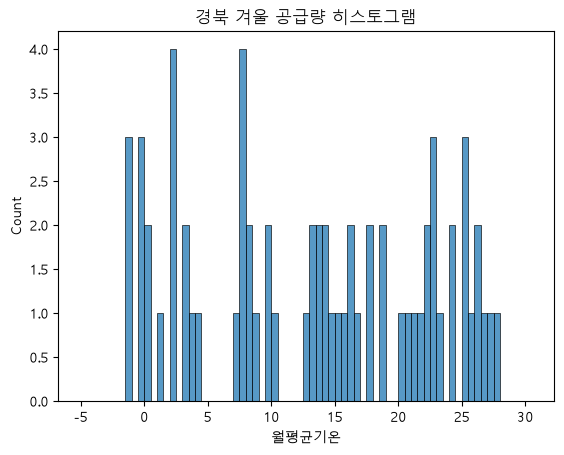

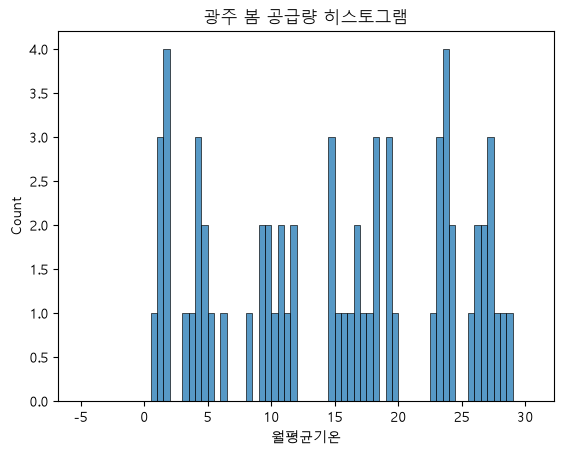

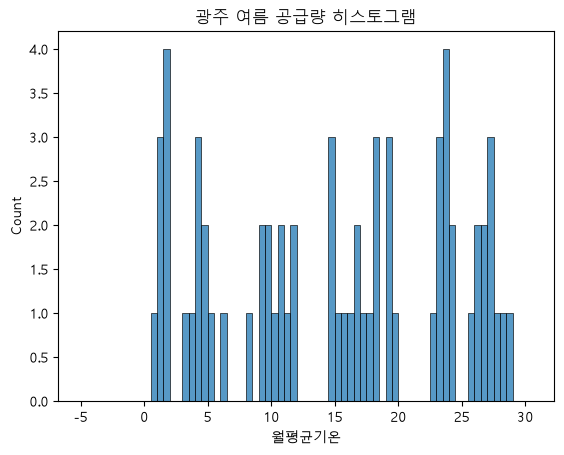

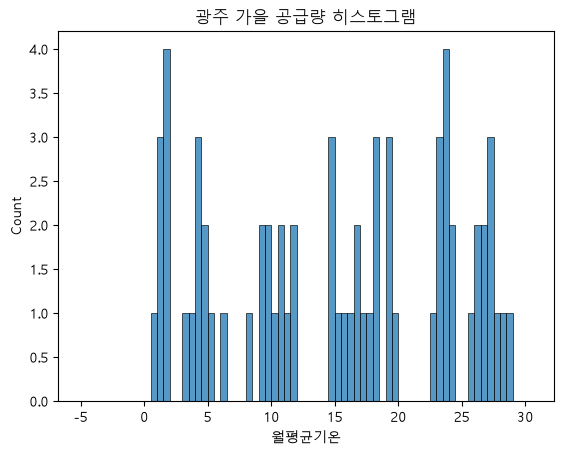

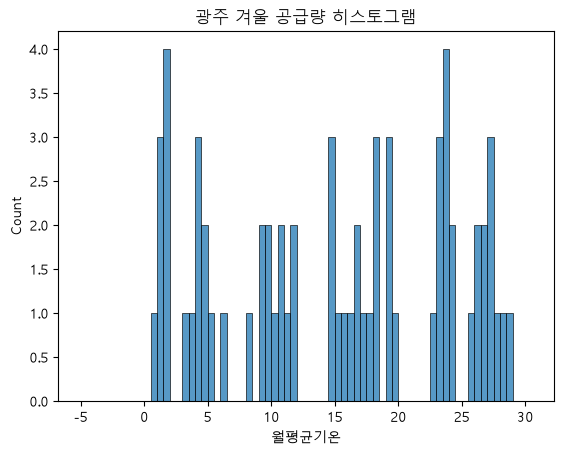

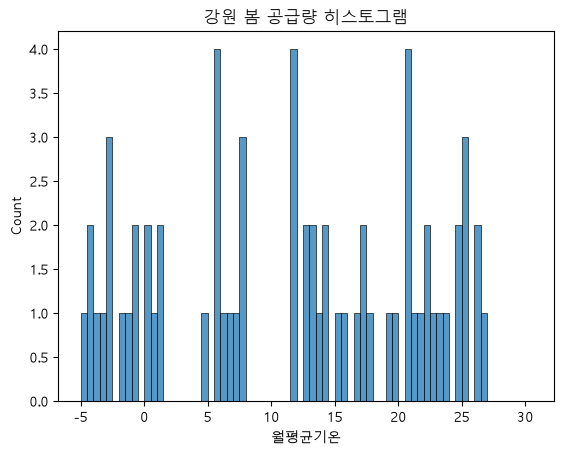

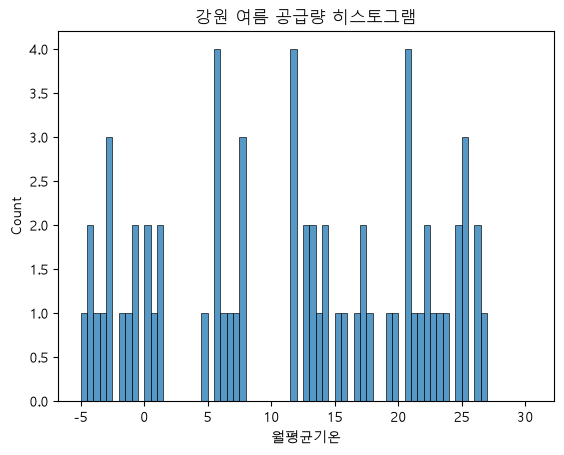

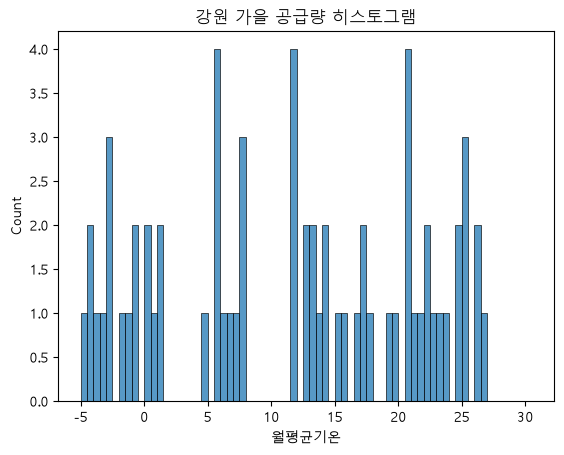

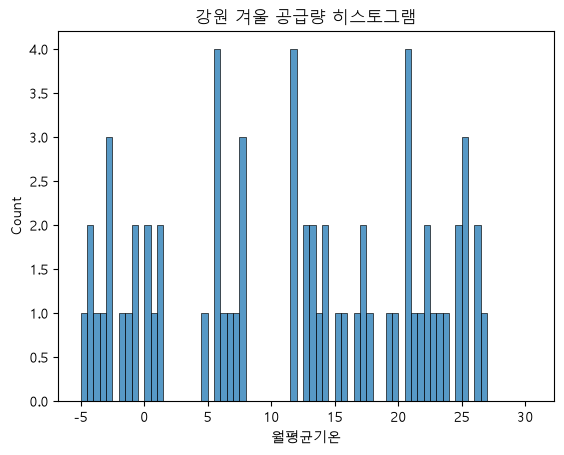

In [ ]:
def get_season(m) : 
  if m in [3,4,5] : return '봄'
  elif m in [6,7,8] : return '여름'
  elif m in [9,10,11] : return '가을'
  else :  return '겨울'

target = ['전북','대전','경남','경북','광주','강원']
filtered_df = df[df['시도'].isin(target)].copy()

filtered_df['월'] = pd.to_datetime(filtered_df['연월']).dt.month
filtered_df['계절'] = filtered_df['월'].apply(get_season)

regions = ['전북','대전','경남','경북','광주','강원']
seasons = ['봄', '여름', '가을', '겨울']

for region in regions : 
  for season in seasons : 
    data = filtered_df[(filtered_df['시도'] == region)]
    sns.histplot(data['월평균기온'], bins=np.arange(-5, 31, 0.5))
    plt.title(f'{region} 월평균 히스토그램')
    plt.show()

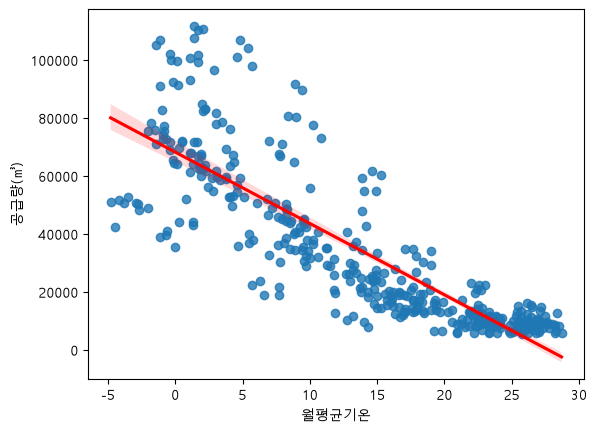

Pearson  상관계수:  -0.841,  p-value:  0.0000
Spearman  상관계수:  -0.895,  p-value:  0.0000


In [13]:
#  추세선까지  추가하면  관계  판단이  쉬움
sns.regplot(x='월평균기온',  y='공급량(㎥)',  data=filtered_df, line_kws={'color':  'red'})
plt.show()

from  scipy.stats  import  pearsonr,  spearmanr
r,  p  =  pearsonr(filtered_df['월평균기온'],  filtered_df['공급량(㎥)'])
print(f"Pearson  상관계수:  {r:.3f},  p-value:  {p:.4f}")
r_s,  p_s  =  spearmanr(filtered_df['월평균기온'],  filtered_df['공급량(㎥)']) 
print(f"Spearman  상관계수:  {r_s:.3f},  p-value:  {p_s:.4f}")

In [36]:
from scipy.stats import pearsonr, spearmanr
import pandas as pd

results = []
for region in regions: 
    df_region = filtered_df[filtered_df['시도'] == region]
    for season in ['봄', '여름', '가을', '겨울']: 
        season_df = df_region[df_region['계절'] == season]
        if len(season_df) > 2:
            r, p = pearsonr(season_df['월평균기온'], season_df['공급량(㎥)'])
            r_s, p_s = spearmanr(season_df['월평균기온'], season_df['공급량(㎥)'])
            results.append([region, season, round(r,3), p, round(r_s,3), p_s])

result_df = pd.DataFrame(results, columns=['지역','계절','Pearson r','Pearson p','Spearman r','Spearman p'])

# 소수점 자리수 늘려서 출력
pd.set_option('display.float_format', lambda x: f'{x:.6f}')
print(result_df)


#강한 음 상관관계 반비례!
#pearson p 0.05 이하면 통계적으로 유의미!


    지역  계절  Pearson r  Pearson p  Spearman r  Spearman p
0   전북   봄  -0.983000   0.000000   -0.969000    0.000000
1   전북  여름  -0.847000   0.000035   -0.730000    0.001327
2   전북  가을  -0.952000   0.000000   -0.989000    0.000000
3   전북  겨울  -0.940000   0.000000   -0.945000    0.000000
4   대전   봄  -0.978000   0.000000   -0.959000    0.000000
5   대전  여름  -0.816000   0.000116   -0.777000    0.000395
6   대전  가을  -0.942000   0.000000   -0.981000    0.000000
7   대전  겨울  -0.902000   0.000001   -0.922000    0.000000
8   경남   봄  -0.966000   0.000000   -0.929000    0.000000
9   경남  여름  -0.930000   0.000000   -0.833000    0.000062
10  경남  가을  -0.931000   0.000000   -0.971000    0.000000
11  경남  겨울  -0.242000   0.348526   -0.181000    0.487379
12  경북   봄  -0.980000   0.000000   -0.961000    0.000000
13  경북  여름  -0.854000   0.000025   -0.812000    0.000134
14  경북  가을  -0.960000   0.000000   -0.963000    0.000000
15  경북  겨울  -0.917000   0.000000   -0.912000    0.000000
16  광주   봄  -0.980000   0.00000

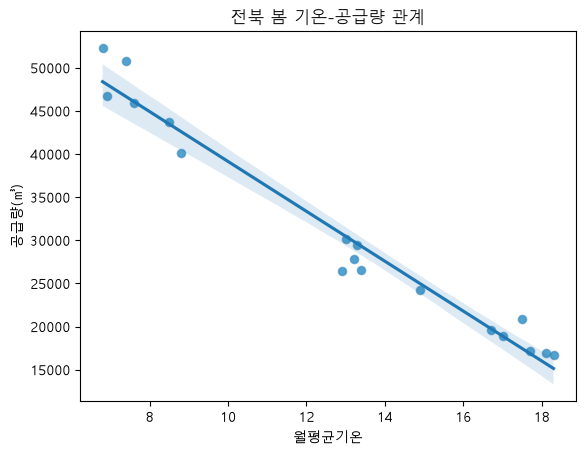

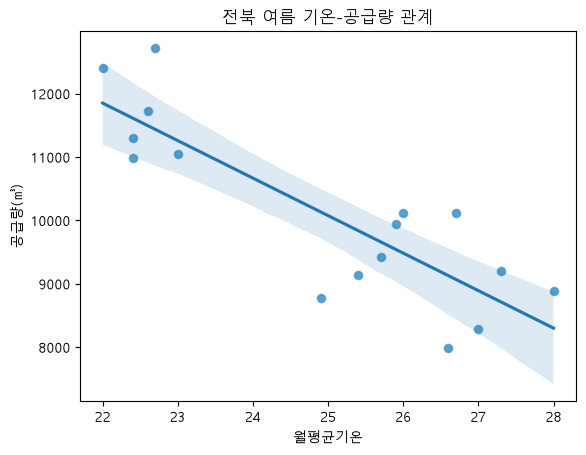

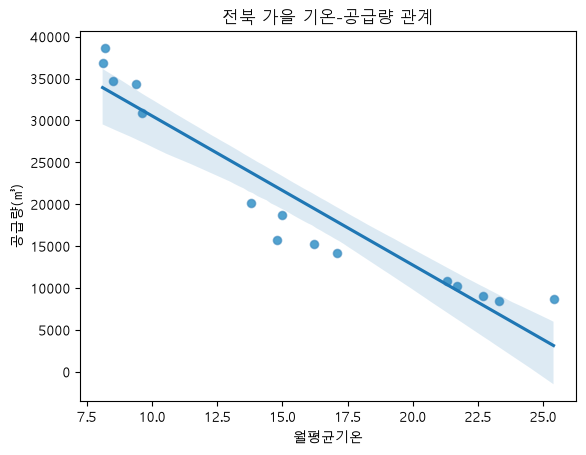

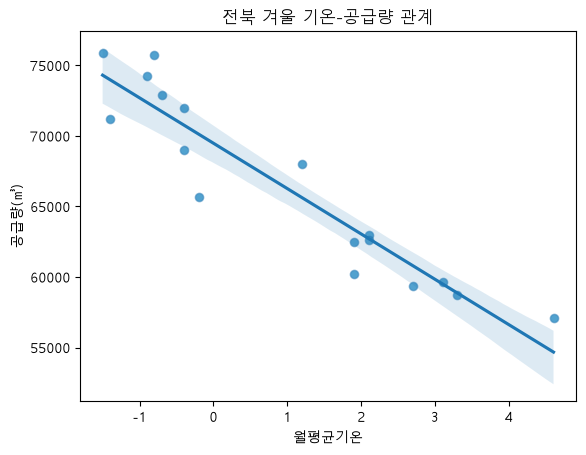

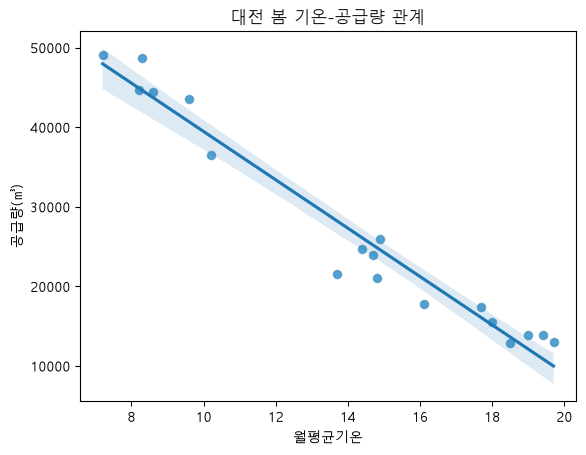

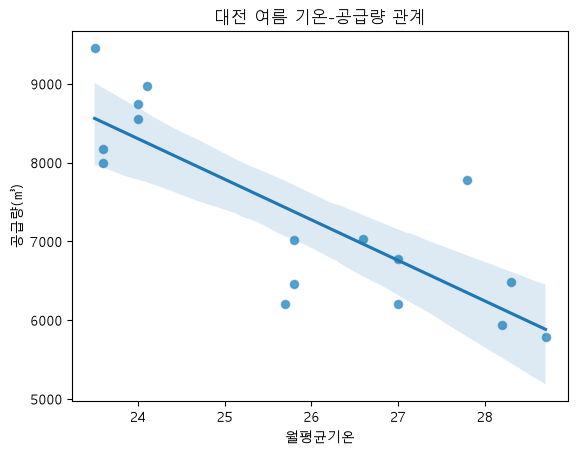

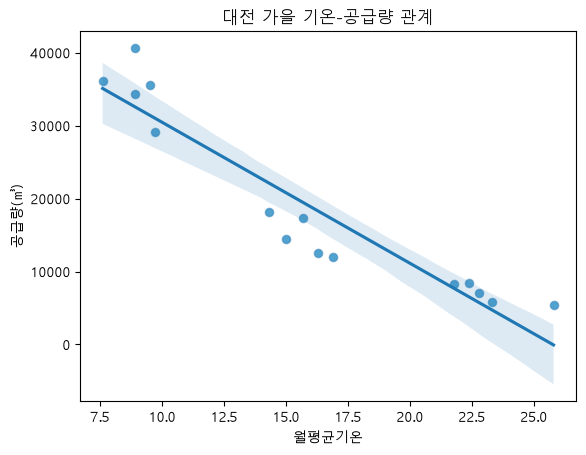

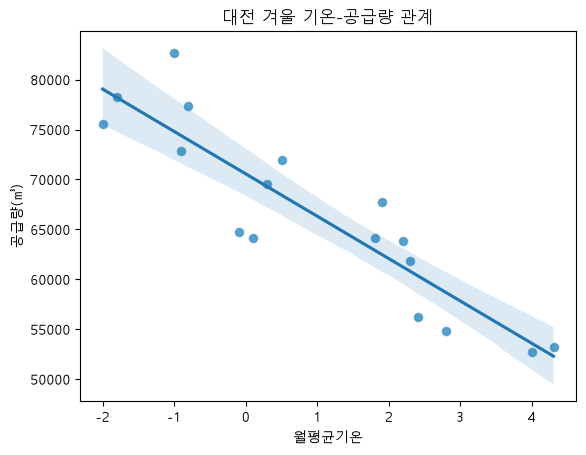

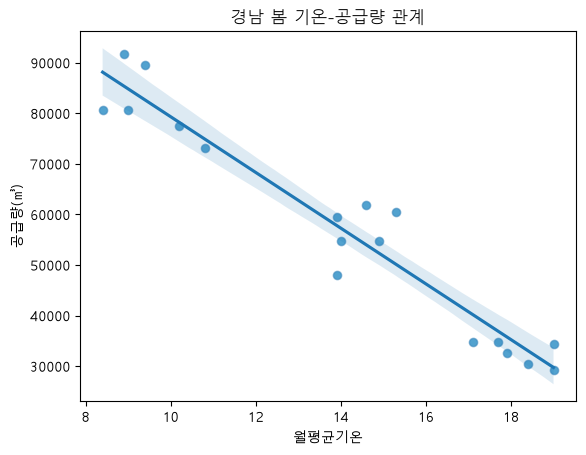

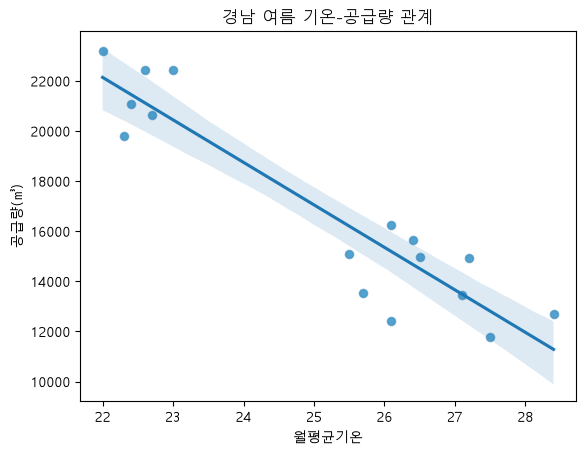

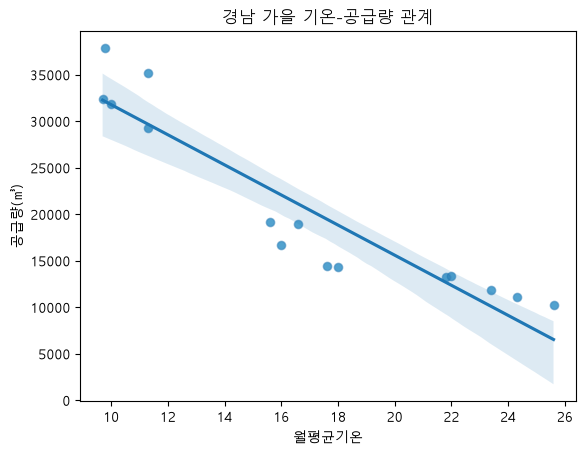

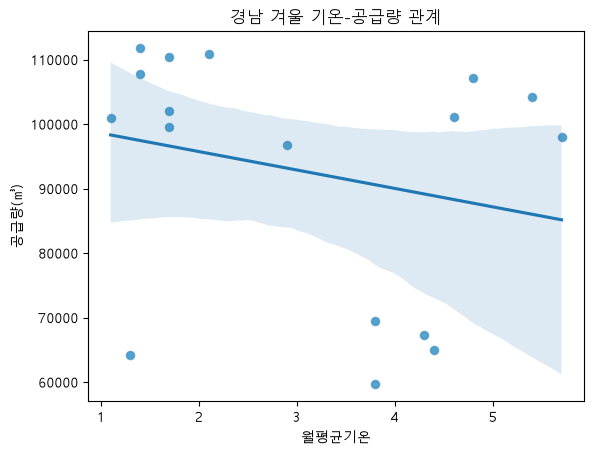

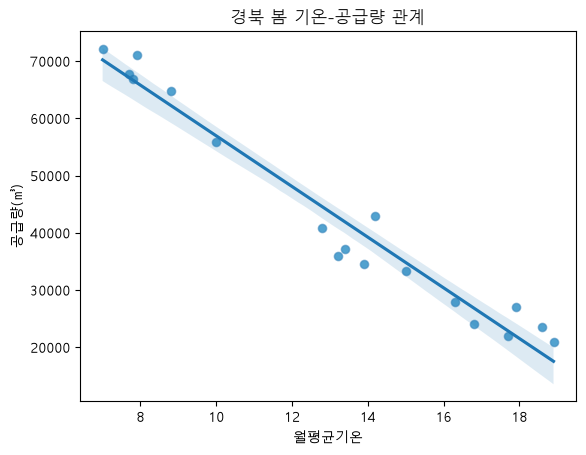

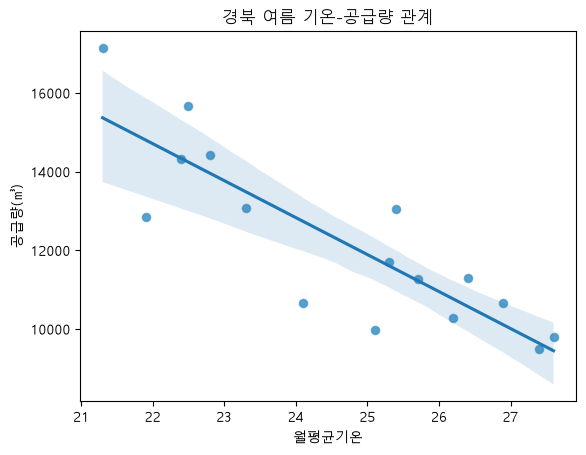

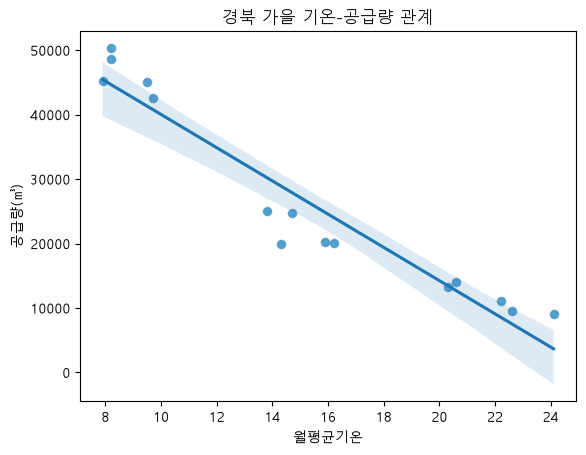

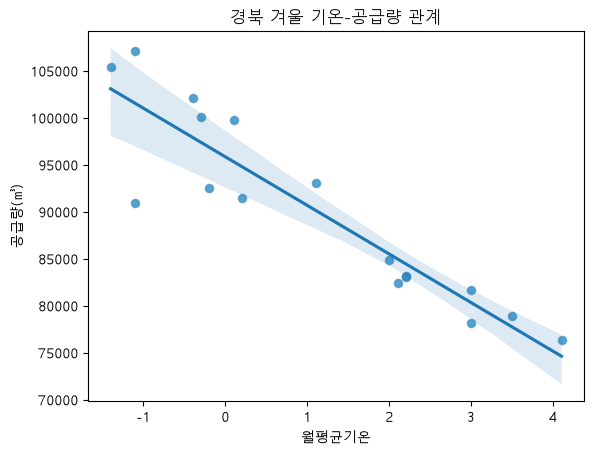

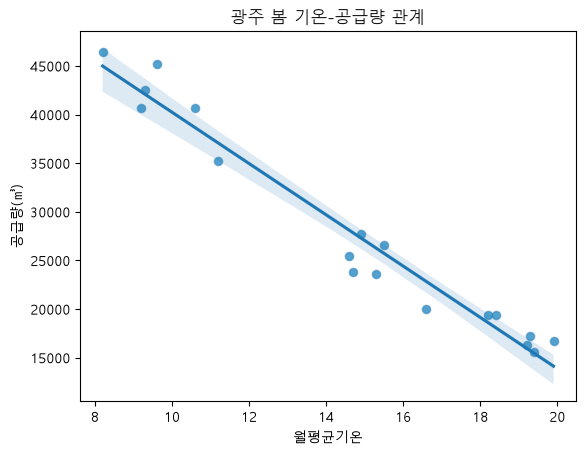

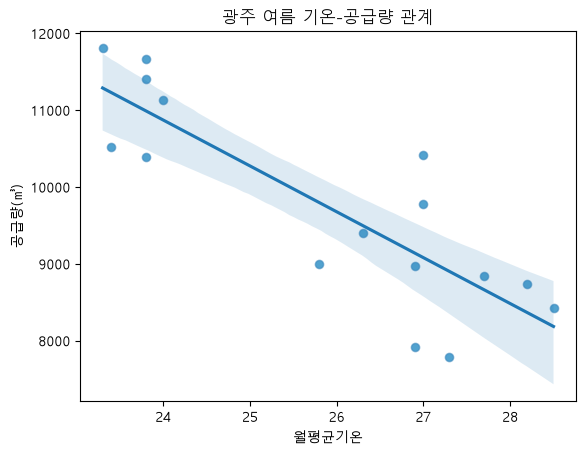

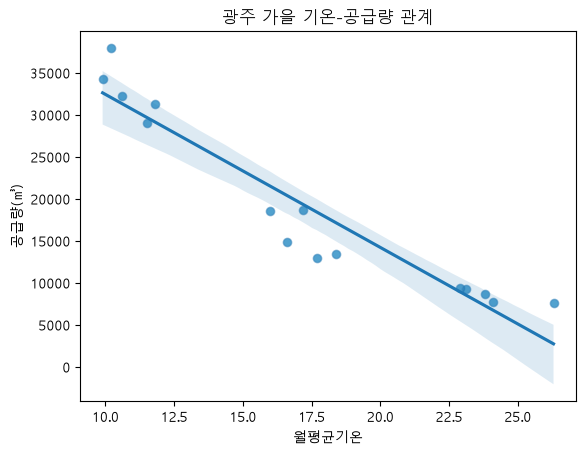

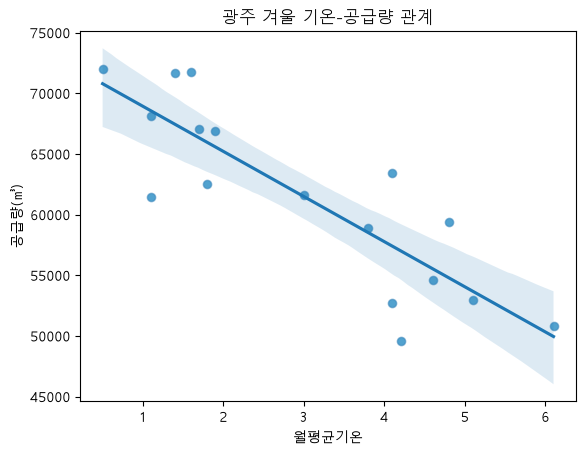

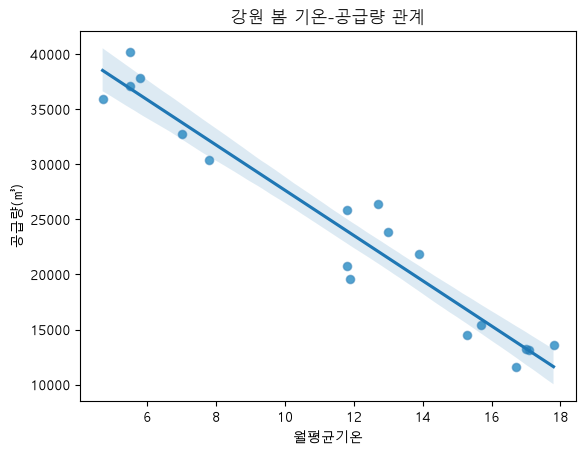

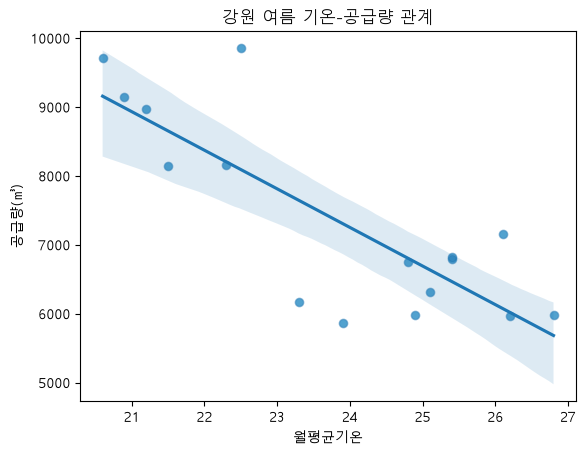

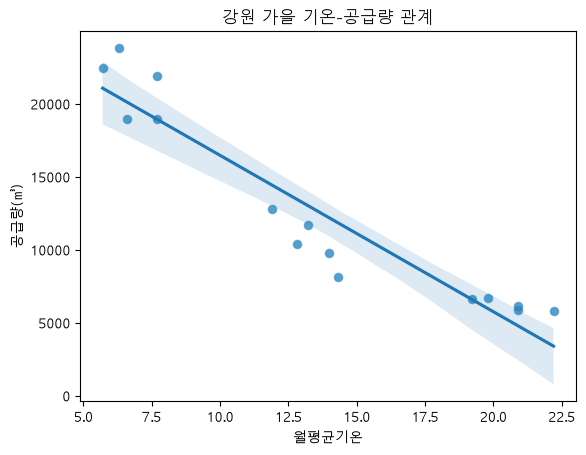

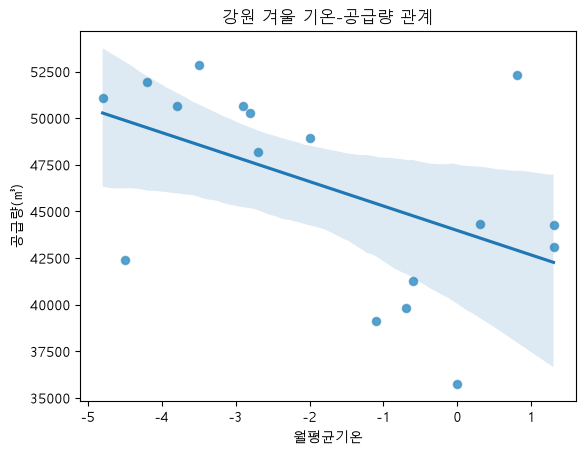

In [ ]:
#산점도 : 관계 확인용 / 두 변수의 관계를 보여준다
#기온이 올라갈 수록 공급량이 줄어든다는 것을 확인 -> 음의 상관관계 확인/
for region in regions:
    for season in seasons:
        data = filtered_df[(filtered_df['시도'] == region) & (filtered_df['계절'] == season)]
        if not data.empty:
            sns.scatterplot(x='월평균기온', y='공급량(㎥)', data=data, color='skyblue')
            plt.title(f'{region} {season} 기온-공급량 관계')
            plt.xlabel('월평균기온(℃)')
            plt.ylabel('공급량(㎥)')
            sns.regplot(x='월평균기온', y='공급량(㎥)', data=data, scatter_kws={'alpha':0.5})
            plt.show()

#회귀선에 밀집되어 있는가를 본다 => 기온과 공급량의 관계가 얼마나 강한지를 볼 수 있다 => 강한 상관관계 / 약한상관관계는 다른 요인도 영향을 준다는 신호



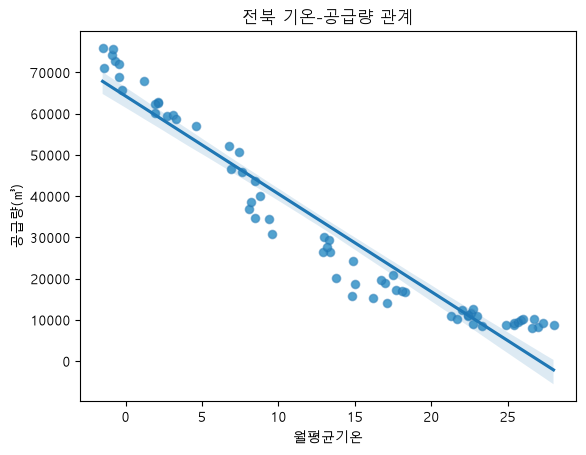

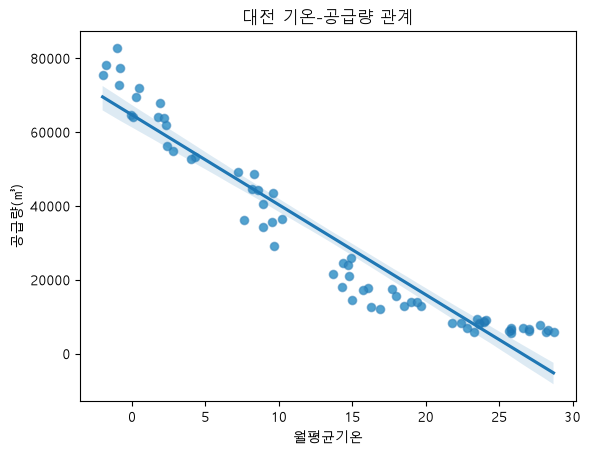

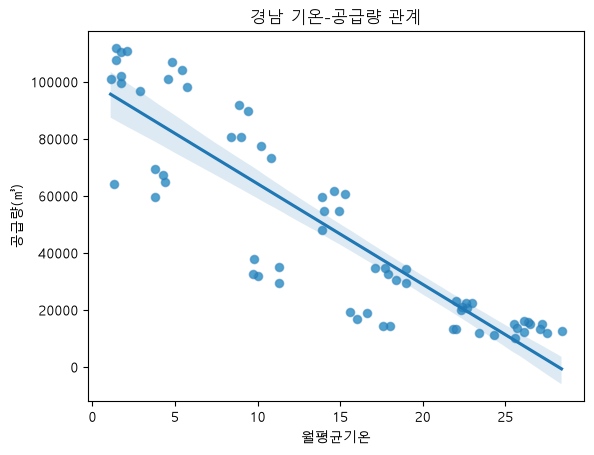

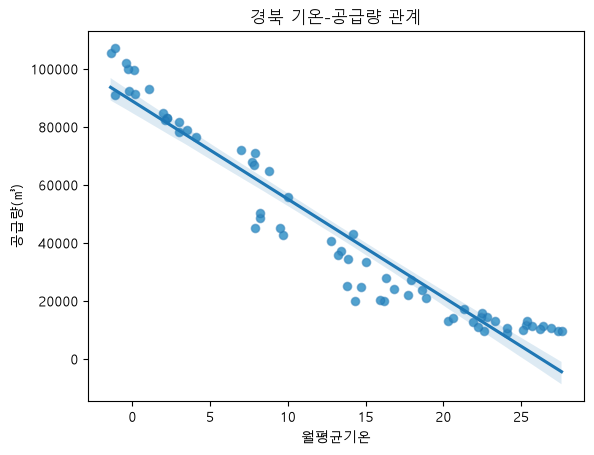

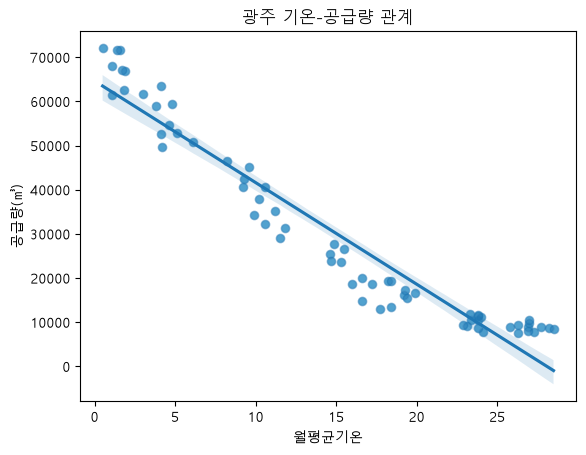

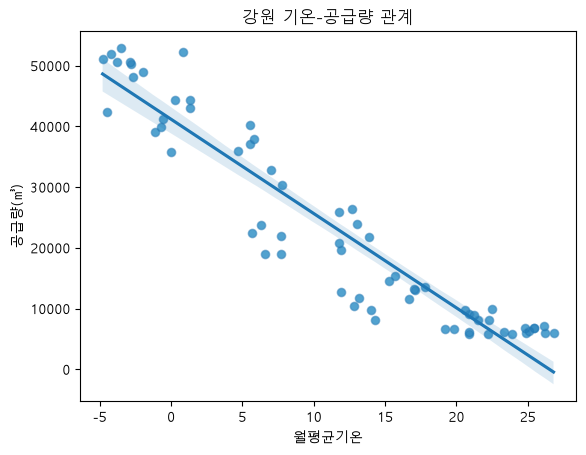

In [ ]:

for region in regions:
      data = filtered_df[(filtered_df['시도'] == region)]
      if not data.empty:
          sns.scatterplot(x='월평균기온', y='공급량(㎥)', data=data, color='skyblue')
          plt.title(f'{region} 기온-공급량 관계')
          plt.xlabel('월평균기온(℃)')
          plt.ylabel('공급량(㎥)')
          sns.regplot(x='월평균기온', y='공급량(㎥)', data=data, scatter_kws={'alpha':0.5})
          plt.show()

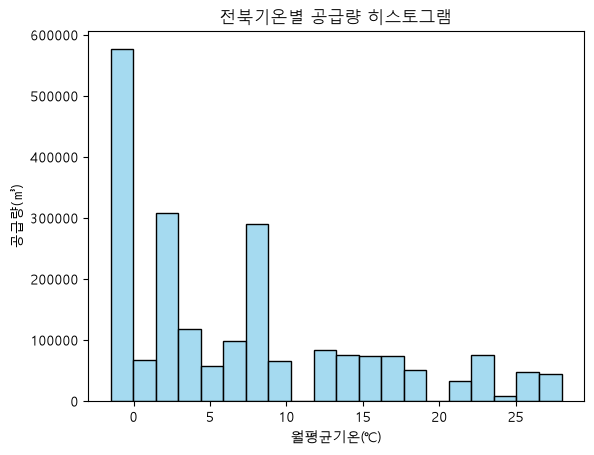

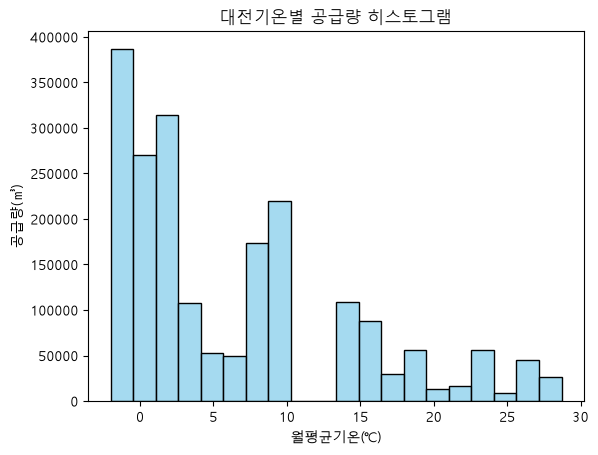

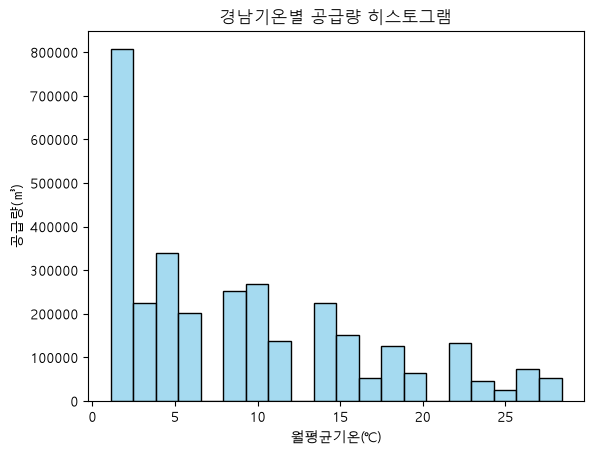

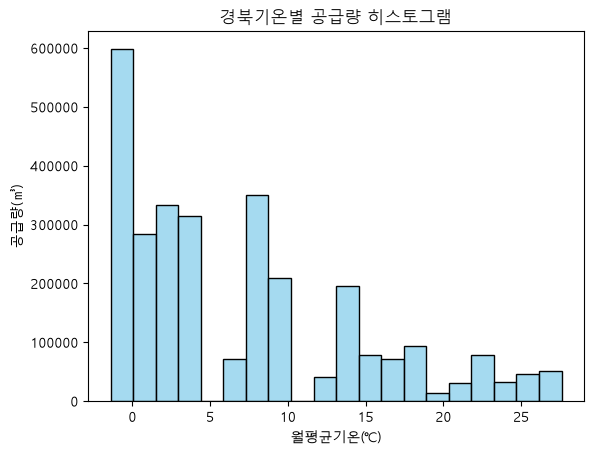

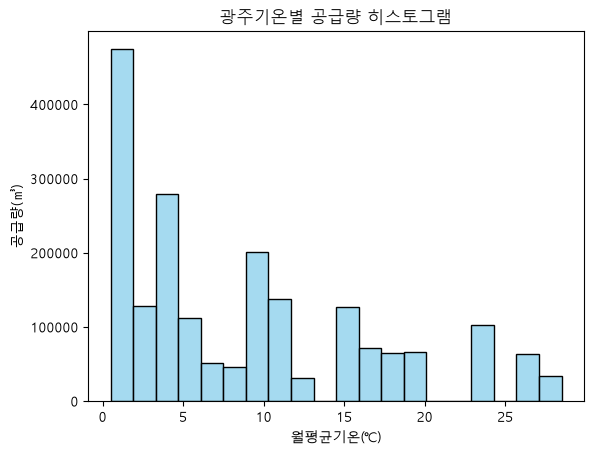

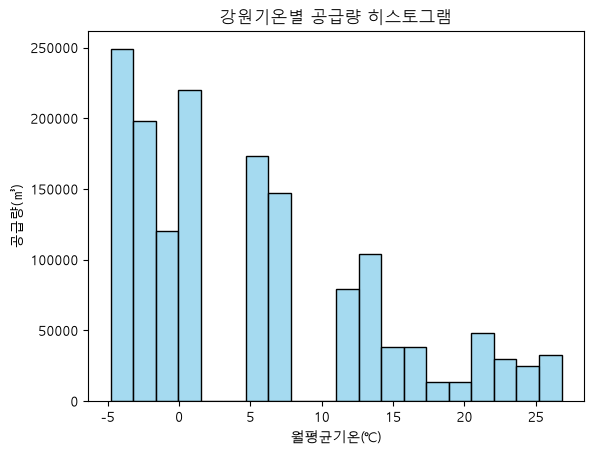

In [ ]:
#히스토그램 : 분포 확인용 => 공급량이 어느 구간에 몰려있는지
#전북의 경우 0도 근처에서 민감하게 반응한다는 것을 보여준다.
#강원의 경우 평균기온의 넓이?가 더 넓다/ 강원은 더 낮은 구간이 존재하고 그 구간에서 공급량이 크게 증가한다=공급량변화도 더 크다  => 강원이 5개 지역 대비 겨울철 한파를 직접적으로 겪는 지역이다.

import seaborn as sns
import matplotlib.pyplot as plt

for region in regions:
        data = filtered_df[(filtered_df['시도'] == region)]
        if not data.empty:
            # 기온을 구간으로 나누고 공급량 분포 확인
            sns.histplot(data=data, x='월평균기온', weights=data['공급량(㎥)'], bins=20, color='skyblue')
            plt.title(f'{region}기온별 공급량 히스토그램')
            plt.xlabel('월평균기온(℃)')
            plt.ylabel('공급량(㎥)')
            plt.show()
